In [25]:
import os
import glob
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# --- CELDA 1: EXTRACCIÓN DE DATOS DE LOS PDFs ---

def extract_from_pdf(pdf_path):
    """Extrae la tabla de resultados de la última página del reporte."""
    filename = os.path.basename(pdf_path).lower()
    
    # 1. Metadatos del nombre de archivo
    model = 'SIBYLL' if 'sib' in filename else 'QGSJet' if 'qgs' in filename else 'EPOS' if 'epos' in filename else 'Unknown'
    
    if 'proton' in filename: primary = 'Proton'
    elif 'iron' in filename or 'hierro' in filename: primary = 'Hierro'
    elif 'helium' in filename or 'helio' in filename: primary = 'Helio'
    elif 'oxygen' in filename or 'oxigeno' in filename: primary = 'Oxigeno'
    else: primary = 'Unknown'
    
    # Lógica de energía (si dice 18 pero no 17 -> 18.0)
    energy = '18.0' if '18' in filename and '17' not in filename else '17.5'

    # 2. Extracción de Tabla
    data = []
    try:
        with pdfplumber.open(pdf_path) as pdf:
            page = pdf.pages[-1] # Última página
            table = page.extract_table()
            
            # Buscar dónde empiezan los datos (saltar header)
            start_idx = 0
            for i, row in enumerate(table):
                # Buscamos la fila que tiene los datos numéricos (asumiendo estructura v5)
                # El header suele tener texto, los datos empiezan después.
                # Un hack simple: si la primera col parece un rango "0.0-21.x"
                if row[0] and "-" in str(row[0]) and any(c.isdigit() for c in str(row[0])):
                    start_idx = i
                    break
            
            # Si no encontró un inicio claro, probamos desde la fila 1 (asumiendo fila 0 es header)
            if start_idx == 0: start_idx = 1

            for row in table[start_idx:]:
                # Limpiar None y saltos de línea
                clean_row = [str(x).replace('\n', ' ') if x is not None else '' for x in row]
                # Filtrar vacíos
                vals = [x for x in clean_row if x.strip() != '']
                
                if len(vals) < 7: continue # Necesitamos al menos 7 columnas (Range, A1_UMD, Err, A1_MC, Err, A1_SD, Err)

                # Parsear valores
                try:
                    theta_range = vals[0]
                    # Asumiendo orden v5: [Range, A1_UMD, Err_UMD, A1_MC, Err_MC, A1_SD, Err_SD]
                    d = {
                        'Primary': primary,
                        'Model': model,
                        'Energy': energy,
                        'Theta_Range': theta_range,
                        # UMD REC
                        'A1_UMD': float(vals[1]),
                        'Err_UMD': float(vals[2]),
                        # UMD MC
                        'A1_MC': float(vals[3]),
                        'Err_MC': float(vals[4]),
                        # SD REC
                        'A1_SD': float(vals[5]),
                        'Err_SD': float(vals[6])
                    }
                    data.append(d)
                except ValueError:
                    continue # Saltar filas de texto basura
    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        
    return pd.DataFrame(data)

In [27]:
# --- EJECUCIÓN PRINCIPAL ---
pdf_files = glob.glob("Reporte_Final_*.pdf")
all_data = []

print(f"Encontrados {len(pdf_files)} reportes.")

for f in pdf_files:
    print(f"Procesando: {f}...")
    df_file = extract_from_pdf(f)
    all_data.append(df_file)

if all_data:
    df_final = pd.concat(all_data, ignore_index=True)
    # Generar índice numérico de bin para plotear fácil
    # Asumimos que el orden de aparición es el orden del bin (0 a 5)
    # Esto reinicia el contador de bin para cada grupo único de simulación
    df_final['Bin_Idx'] = df_final.groupby(['Primary', 'Model', 'Energy']).cumcount()
    
    # GUARDAR CSV
    df_final.to_csv("datos_tesis_final.csv", index=False)
    print("\n✅ ¡Listo! Datos guardados en 'datos_tesis_final.csv'")
    display(df_final.head())
else:
    print("❌ No se extrajeron datos.")

Encontrados 6 reportes.
Procesando: Reporte_Final_parquet_sib_hierro_17.pdf...
Procesando: Reporte_Final_parquet_qgs_helio_17.pdf...
Procesando: Reporte_Final_parquet_epos_helio_18.pdf...
Procesando: Reporte_Final_parquet_sib_proton_17.pdf...
Procesando: Reporte_Final_parquet_sib_oxigeno_17.pdf...
Procesando: Reporte_Final_parquet_sib_helio_17.pdf...

✅ ¡Listo! Datos guardados en 'datos_tesis_final.csv'


,Primary,Model,Energy,Theta_Range,A1_UMD,Err_UMD,A1_MC,Err_MC,A1_SD,Err_SD,Bin_Idx
0,Hierro,SIBYLL,17.5,0.5-21.7,0.0275,0.0015,0.0309,0.0015,0.0306,0.0012,0
1,Hierro,SIBYLL,17.5,21.7-31.6,0.0522,0.0024,0.0591,0.0024,0.0640,0.0025,1
2,Hierro,SIBYLL,17.5,31.6-39.9,0.0654,0.0021,0.0745,0.0020,0.0941,0.0027,2
3,Hierro,SIBYLL,17.5,39.9-47.7,0.0749,0.0018,0.0862,0.0020,0.1104,0.0032,3
4,Hierro,SIBYLL,17.5,47.7-55.8,0.0742,0.0015,0.0870,0.0015,0.0980,0.0019,4


In [28]:
class AsymmetryPlotter:
    def __init__(self, csv_path="datos_tesis_final.csv"):
        """
        Inicializa el plotter, carga datos, estandariza nombres y define estilos.
        """
        try:
            self.df = pd.read_csv(csv_path)
            print(f"✅ Datos cargados correctamente: {len(self.df)} filas.")
        except FileNotFoundError:
            print(f"❌ Error: No se encontró '{csv_path}'.")
            self.df = pd.DataFrame()
            return

        # --- 1. ROBUSTEZ: Renombrar columnas si vienen del script de extracción ---
        rename_map = {
            'A1_UMD': 'A1_UMD_REC', 'Err_UMD': 'Err_UMD_REC',
            'A1_MC':  'A1_UMD_MC',  'Err_MC':  'Err_UMD_MC', 
            'A1_SD':  'A1_SD_REC',  'Err_SD':  'Err_SD_REC'
        }
        self.df.rename(columns=rename_map, inplace=True)
        
        # --- 2. INDICE DE BINES ---
        if 'Bin_Idx' in self.df.columns and 'Theta_Bin_Idx' not in self.df.columns:
            self.df.rename(columns={'Bin_Idx': 'Theta_Bin_Idx'}, inplace=True)
        elif 'Theta_Bin_Idx' not in self.df.columns:
            self.df['Theta_Bin_Idx'] = self.df.groupby(['Primary', 'Model', 'Energy']).cumcount()

        # --- 3. CONFIGURACIÓN ESTÉTICA ---
        plt.rcParams.update({
            'font.size': 14,
            'axes.titlesize': 16,
            'axes.labelsize': 14,
            'xtick.labelsize': 12,
            'ytick.labelsize': 12,
            'legend.fontsize': 10,
            'figure.figsize': (12, 8),
            'lines.linewidth': 2,
            'lines.markersize': 9,
            'errorbar.capsize': 4
        })

        # Diccionarios de Estilo
        self.colors = {'Proton': 'royalblue', 'Helio': 'forestgreen', 'Hierro': 'firebrick', 'Oxigeno': 'purple'}
        self.markers = {'SIBYLL': 'o', 'QGSJet': 's', 'EPOS': '^'}
        
        # Estilos de línea específicos para discriminación de masa
        self.mass_styles = {
            'Proton': 'o-',   # Circulo, Solido
            'Helio':  's--',  # Cuadrado, Dashed
            'Hierro': '^-.',  # Triangulo, Dash-dot
            'Oxigeno': 'd:'   # Diamante, Dotted
        }

        # Etiquetas
        self.detectors_label = {
            'UMD_REC': r'UMD REC ($N_\mu$)',
            'UMD_MC': r'UMD MC (Verdad)',
            'SD_REC': r'SD REC ($S_{tot}$)'
        }
        self.theta_labels = [r"$0^{\circ}-21^{\circ}$", r"$21^{\circ}-31^{\circ}$", 
                             r"$31^{\circ}-40^{\circ}$", r"$40^{\circ}-48^{\circ}$", 
                             r"$48^{\circ}-56^{\circ}$", r"$56^{\circ}-65^{\circ}$"]

    def _filter_data(self, primary=None, model=None, energy=None):
        df_f = self.df.copy()
        if primary: df_f = df_f[df_f['Primary'] == primary]
        if model: df_f = df_f[df_f['Model'] == model]
        if energy: df_f = df_f[df_f['Energy'] == float(energy)]
        return df_f

    # =========================================================================
    # FUNCIÓN 1: GLOBAL COMPARISON (NUEVA)
    # =========================================================================
    def plot_global_comparison(self, detector='UMD_REC'):
        """
        Plot Maestro: Muestra TODOS los datos.
        - Color: Primario
        - Marker: Modelo
        """
        fig, ax = plt.subplots()
        
        # Agrupar por todo
        groups = self.df.groupby(['Primary', 'Model', 'Energy'])
        
        # Jitter para separar visualmente
        shift_map = {'Proton': -0.14, 'Helio': -0.04, 'Hierro': 0.06, 'Oxigeno': 0.16}

        for (prim, mod, en), group in groups:
            group = group.sort_values('Theta_Bin_Idx')
            
            # Datos
            x = group['Theta_Bin_Idx'].values
            y = group[f'A1_{detector}'].values
            yerr = group[f'Err_{detector}'].values
            
            # Estilos Dinámicos
            c = self.colors.get(prim, 'gray')
            m = self.markers.get(mod, 'o')
            
            # Shift
            x_pos = x + shift_map.get(prim, 0)
            
            label_txt = f"{prim} | {mod} | {en}"
            
            ax.errorbar(x_pos, y, yerr=yerr, 
                        fmt=m, color=c,
                        label=label_txt,
                        capsize=4, elinewidth=1.5)

        # Cosmética
        det_name = self.detectors_label.get(detector, detector)
        ax.set_title(f"Comparación Global Multi-Parámetro: {det_name}", pad=15)
        ax.set_xlabel(r"Rango Angular Cenital ($\theta$)", labelpad=10)
        ax.set_ylabel(r"Amplitud de Asimetría ($A_1$)", labelpad=10)
        
        ax.set_xticks(range(6))
        ax.set_xticklabels(self.theta_labels)
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(ncol=2, loc='upper left', fontsize=9, frameon=True, shadow=True)
        
        plt.tight_layout()
        plt.show()

    # =========================================================================
    # FUNCIÓN 2: DISCRIMINACIÓN DE MASA (ESTILO TESIS)
    # =========================================================================
    def plot_mass_discrimination(self, detector='UMD_REC', model_filter='SIBYLL', energy_filter=17.5):
        fig, ax = plt.subplots()
        
        subset = self._filter_data(model=model_filter, energy=energy_filter)
        if subset.empty:
            print(f"⚠️ No hay datos para {model_filter} a {energy_filter}")
            return

        shifts = {'Proton': -0.1, 'Helio': -0.05, 'Hierro': 0.05, 'Oxigeno': 0.1}
        primaries_present = subset['Primary'].unique()
        
        # Orden forzado para leyenda limpia
        for prim in ['Proton', 'Helio', 'Oxigeno', 'Hierro']:
            if prim not in primaries_present: continue
            
            data = subset[subset['Primary'] == prim].sort_values('Theta_Bin_Idx')
            if len(data) == 0: continue

            x = data['Theta_Bin_Idx'].values + shifts.get(prim, 0)
            y = data[f'A1_{detector}'].values
            yerr = data[f'Err_{detector}'].values
            
            # Estilo específico por masa (tu pedido)
            fmt_style = self.mass_styles.get(prim, 'o-')
            
            ax.errorbar(x, y, yerr=yerr, fmt=fmt_style, 
                        color=self.colors.get(prim, 'gray'),
                        label=f'{prim}', 
                        capsize=4, alpha=0.9, elinewidth=2)

        det_name = self.detectors_label.get(detector, detector)
        ax.set_title(f"Discriminación de Masa: {det_name}\n({model_filter} @ {energy_filter} log eV)")
        ax.set_ylabel(r"Amplitud de Asimetría $A_1$")
        ax.set_xlabel(r"Rango Angular Cenital ($\theta$)", labelpad=10)
        ax.set_xticks(range(6))
        ax.set_xticklabels(self.theta_labels)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(title="Primario")
        
        plt.tight_layout()
        plt.show()

    # =========================================================================
    # FUNCIÓN 3: COMPARACIÓN DE MODELOS
    # =========================================================================
    def plot_model_comparison(self, primary='Helio', detector='UMD_REC'):
        fig, ax = plt.subplots()
        
        subset = self._filter_data(primary=primary)
        shifts = {'SIBYLL': -0.1, 'QGSJet': 0.0, 'EPOS': 0.1}
        models_present = subset['Model'].unique()
        
        for model in models_present:
            data = subset[subset['Model'] == model].sort_values('Theta_Bin_Idx')
            
            # Elegir energía preferente 17.5
            energies = data['Energy'].unique()
            if len(energies) > 0:
                target_e = 17.5 if 17.5 in energies else energies[0]
                data_e = data[data['Energy'] == target_e]
                label_extra = f" ({target_e})"
            else: continue

            x = data_e['Theta_Bin_Idx'].values + shifts.get(model, 0)
            y = data_e[f'A1_{detector}'].values
            yerr = data_e[f'Err_{detector}'].values
            
            marker = self.markers.get(model, 'o')
            
            # Diferenciamos modelos también por tipo de línea
            ls = '-' if model == 'SIBYLL' else '--' if model == 'QGSJet' else '-.'
            
            ax.errorbar(x, y, yerr=yerr, marker=marker, linestyle=ls,
                        color=self.colors.get(primary, 'black'),
                        label=f'{model}{label_extra}',
                        capsize=4)

        ax.set_title(f"Comparación de Modelos: {primary} - {self.detectors_label.get(detector)}")
        ax.set_ylabel(r"$A_1$")
        ax.set_xlabel(r"$\theta$")
        ax.set_xticks(range(6))
        ax.set_xticklabels(self.theta_labels)
        ax.legend(title="Modelo Hadrónico")
        ax.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # =========================================================================
    # FUNCIÓN 4: FÍSICA DEL DETECTOR (INDIVIDUALES)
    # =========================================================================
    def plot_detector_physics(self):
        groups = self.df.groupby(['Primary', 'Model', 'Energy'])
        
        for (prim, mod, en), group in groups:
            group = group.sort_values('Theta_Bin_Idx')
            
            fig, ax = plt.subplots(figsize=(8, 6))
            x = group['Theta_Bin_Idx'].values
            
            # UMD REC (Azul solido)
            ax.plot(x, group['A1_UMD_REC'], 'o-', color='navy', label='UMD REC')
            ax.fill_between(x, group['A1_UMD_REC']-group['Err_UMD_REC'], group['A1_UMD_REC']+group['Err_UMD_REC'], color='navy', alpha=0.15)
            
            # UMD MC (Verde punteado)
            ax.plot(x, group['A1_UMD_MC'], 's--', color='green', label='UMD MC', alpha=0.6)
            
            # SD REC (Rojo punto-raya)
            ax.plot(x, group['A1_SD_REC'], '^-.', color='firebrick', label='SD REC')
            ax.fill_between(x, group['A1_SD_REC']-group['Err_SD_REC'], group['A1_SD_REC']+group['Err_SD_REC'], color='firebrick', alpha=0.15)
            
            ax.set_title(f"Física del Detector: {prim} | {mod} | {en} log eV")
            ax.set_ylabel(r"$A_1$")
            ax.set_xticks(range(6))
            ax.set_xticklabels(self.theta_labels)
            ax.legend()
            ax.grid(True, alpha=0.5)
            
            if prim == 'Proton':
                val_max = group['A1_SD_REC'].max()
                if not np.isnan(val_max):
                    ax.text(2.5, val_max*0.8, r"SD > UMD (Componente EM)", 
                            color='firebrick', ha='center', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

            plt.tight_layout()
            plt.show()

✅ Datos cargados correctamente: 36 filas.
--- 1. PLOT GLOBAL (MONEY PLOT) ---


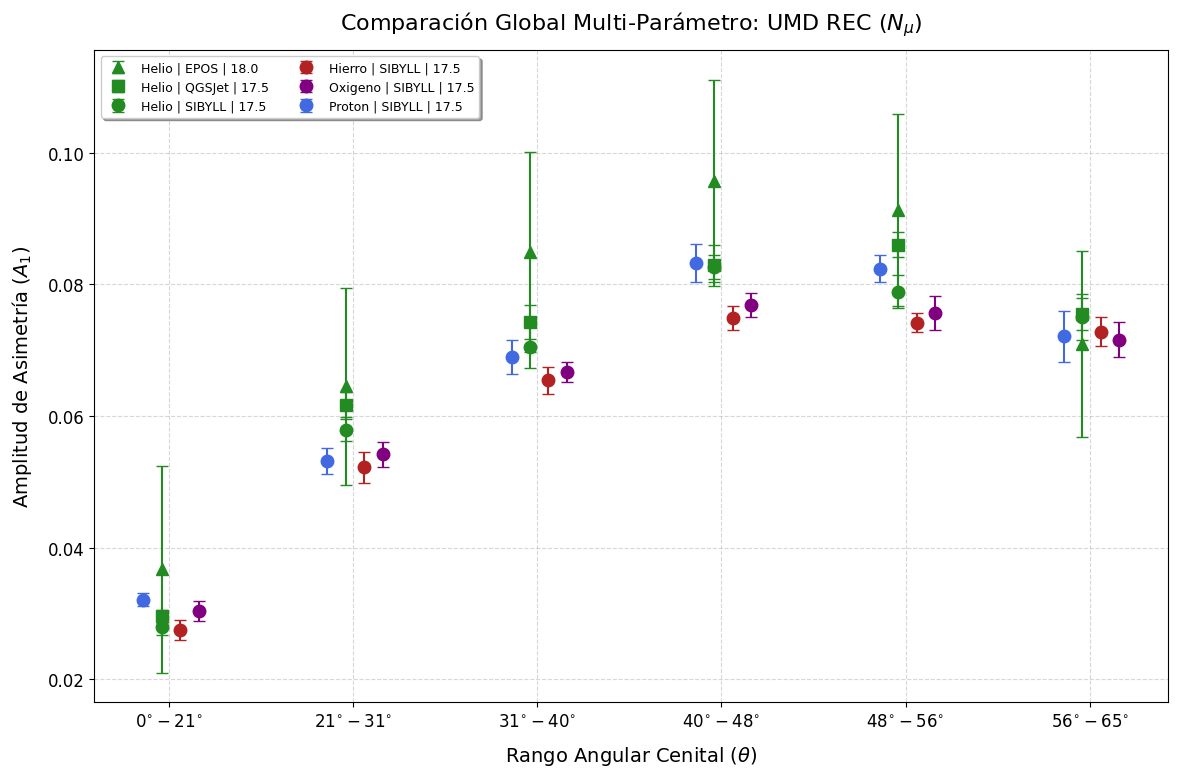


--- 2. DISCRIMINACIÓN DE MASA (SIBYLL) ---


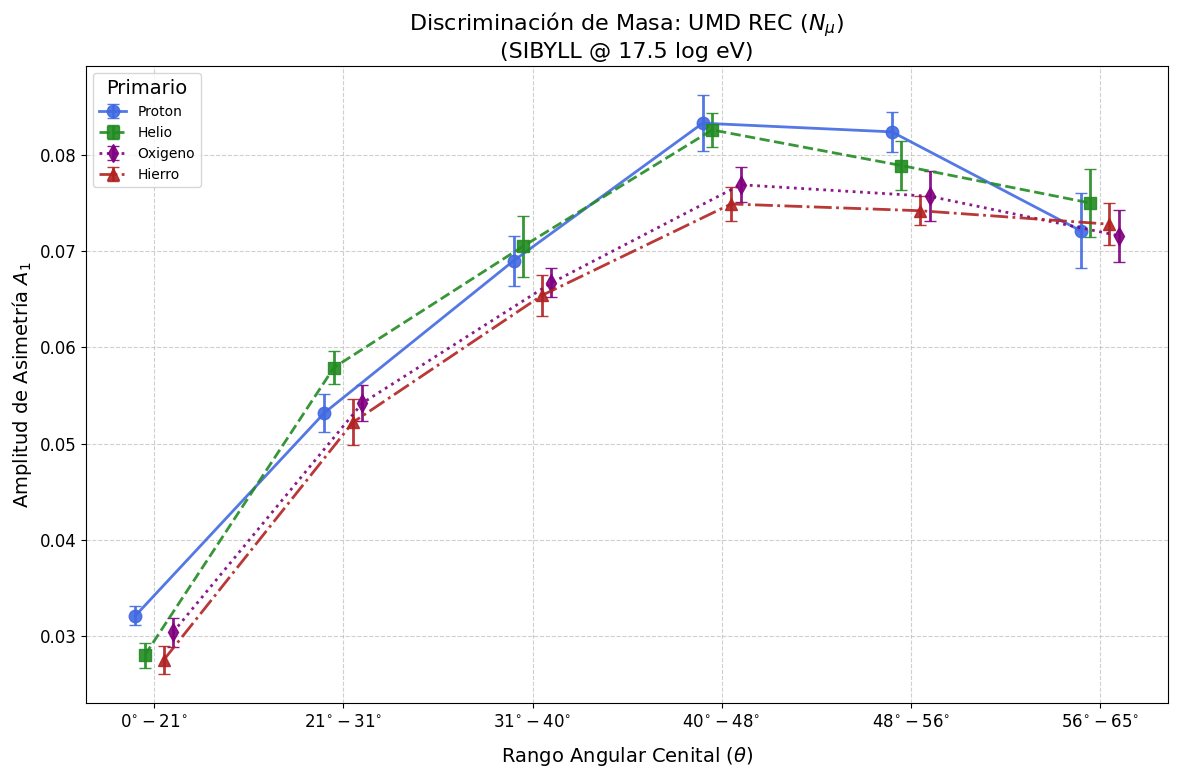


--- 3. COMPARACIÓN DE MODELOS (HELIO) ---


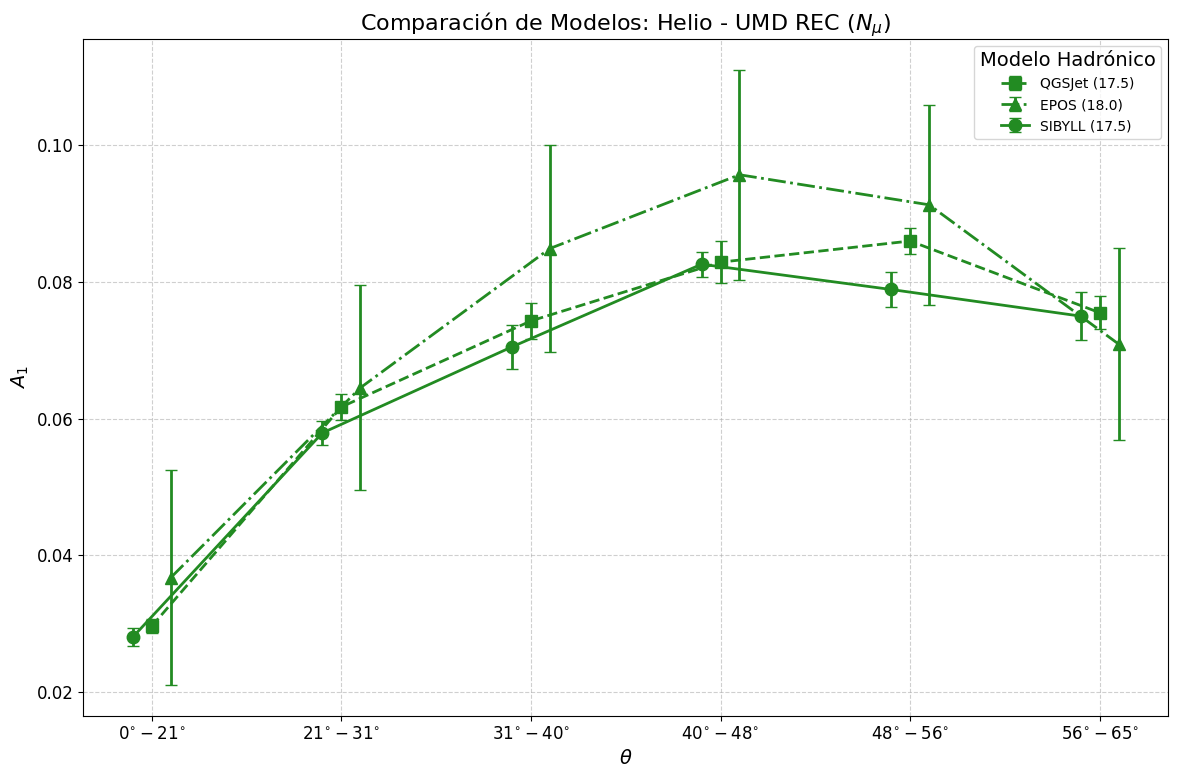

In [37]:
plotter = AsymmetryPlotter("datos_tesis_final.csv")

print("--- 1. PLOT GLOBAL (MONEY PLOT) ---")
# Probá cambiar detector a 'SD_REC' para ver la diferencia
plotter.plot_global_comparison(detector='UMD_REC')

print("\n--- 2. DISCRIMINACIÓN DE MASA (SIBYLL) ---")
plotter.plot_mass_discrimination(detector='UMD_REC', model_filter='SIBYLL', energy_filter=17.5)

print("\n--- 3. COMPARACIÓN DE MODELOS (HELIO) ---")
plotter.plot_model_comparison(primary='Helio', detector='UMD_REC')

#print("\n--- 4. FÍSICA DETECTOR (TODOS) ---")
#plotter.plot_detector_physics()

✅ Datos cargados: 36 simulaciones.


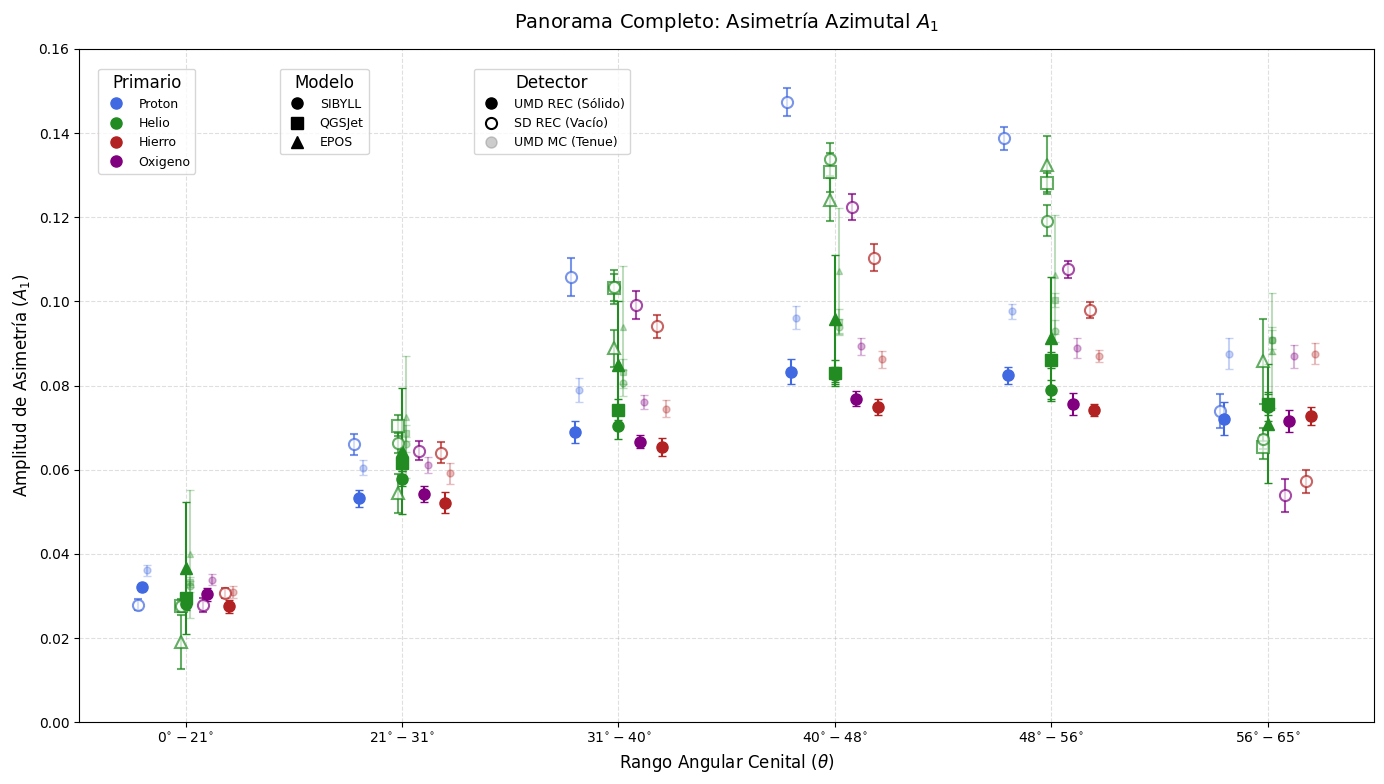

✅ Gráfico guardado: Grand_Finale_NoLines.png


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- 1. CARGAR DATOS ---
try:
    df = pd.read_csv("datos_tesis_final.csv")
    
    # Estandarizar nombres
    rename_map = {
        'A1_UMD': 'A1_UMD_REC', 'Err_UMD': 'Err_UMD_REC',
        'A1_MC':  'A1_UMD_MC',  'Err_MC':  'Err_UMD_MC', 
        'A1_SD':  'A1_SD_REC',  'Err_SD':  'Err_SD_REC'
    }
    df.rename(columns=rename_map, inplace=True)
    
    if 'Theta_Bin_Idx' not in df.columns:
        df['Theta_Bin_Idx'] = df.groupby(['Primary', 'Model', 'Energy']).cumcount()

    print(f"✅ Datos cargados: {len(df)} simulaciones.")

except FileNotFoundError:
    print("❌ Error: No se encontró 'datos_tesis_final.csv'.")
    df = pd.DataFrame()

# --- 2. CONFIGURACIÓN VISUAL ---
plt.rcParams.update({
    'font.size': 12,
    'figure.figsize': (14, 8),
    'errorbar.capsize': 3,
    'lines.linewidth': 1.5,
    'lines.markersize': 8
})

theta_labels = [r"$0^{\circ}-21^{\circ}$", r"$21^{\circ}-31^{\circ}$", 
                r"$31^{\circ}-40^{\circ}$", r"$40^{\circ}-48^{\circ}$", 
                r"$48^{\circ}-56^{\circ}$", r"$56^{\circ}-65^{\circ}$"]

# --- MAPEOS ---
# Color = Primario
colors = {
    'Proton': 'royalblue', 'Helio': 'forestgreen', 
    'Hierro': 'firebrick', 'Oxigeno': 'purple', 'Oxígeno': 'purple'
}

# Forma = Modelo
model_markers = {
    'SIBYLL': 'o',  # Círculo
    'QGSJet': 's',  # Cuadrado
    'EPOS':   '^'   # Triángulo (suele ser alta energía)
}

# --- 3. PLOTEO ---
fig, ax = plt.subplots()

groups = df.groupby(['Primary', 'Model', 'Energy'])

# Shifts para que no se pisen (Jitter Horizontal)
prim_shift = {'Proton': -0.2, 'Helio': 0.0, 'Oxigeno': 0.1, 'Hierro': 0.2}
det_shift  = {'UMD_REC': 0.0, 'UMD_MC': 0.02, 'SD_REC': -0.02}

for (prim, mod, en), group in groups:
    group = group.sort_values('Theta_Bin_Idx')
    x_base = group['Theta_Bin_Idx'].values
    
    c = colors.get(prim, 'gray')
    m = model_markers.get(mod, 'o')
    x_prim = x_base + prim_shift.get(prim, 0)
    
    # 1. UMD MC (Verdad) -> Chico y Transparente
    ax.errorbar(x_prim + det_shift['UMD_MC'], 
                group['A1_UMD_MC'], yerr=group['Err_UMD_MC'], 
                fmt=m, color=c, alpha=0.3, markersize=5, 
                label='_nolegend_')

    # 2. SD REC -> Vacío (Solo Borde)
    ax.errorbar(x_prim + det_shift['SD_REC'], 
                group['A1_SD_REC'], yerr=group['Err_SD_REC'], 
                fmt=m, color=c, mfc='white', mec=c, mew=1.5, # Relleno blanco, borde color
                alpha=0.7, label='_nolegend_')

    # 3. UMD REC -> Sólido (Principal)
    ax.errorbar(x_prim + det_shift['UMD_REC'], 
                group['A1_UMD_REC'], yerr=group['Err_UMD_REC'], 
                fmt=m, color=c, mfc=c, # Relleno color
                alpha=1.0, label='_nolegend_')

# --- 4. COSMÉTICA Y LEYENDAS ---
ax.set_title(r"Panorama Completo: Asimetría Azimutal $A_1$", pad=15)
ax.set_ylabel(r"Amplitud de Asimetría ($A_1$)")
ax.set_xlabel(r"Rango Angular Cenital ($\theta$)")
ax.set_xticks(range(6))
ax.set_xticklabels(theta_labels)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.set_ylim(0, 0.16)

# --- LEYENDAS PERSONALIZADAS ---

# A. Primarios (Colores)
leg_prim = [Line2D([0],[0], color=v, marker='o', lw=0, label=k) for k,v in colors.items() if k != 'Oxígeno']
l1 = plt.legend(handles=leg_prim, title="Primario", loc='upper left', bbox_to_anchor=(0.01, 0.98))
ax.add_artist(l1)

# B. Modelos (Formas)
leg_mod = [
    Line2D([0],[0], color='k', marker='o', lw=0, label='SIBYLL'),
    Line2D([0],[0], color='k', marker='s', lw=0, label='QGSJet'),
    Line2D([0],[0], color='k', marker='^', lw=0, label='EPOS')
]
l2 = plt.legend(handles=leg_mod, title="Modelo", loc='upper left', bbox_to_anchor=(0.15, 0.98))
ax.add_artist(l2)

# C. Detectores (Estilos de Relleno)
leg_det = [
    Line2D([0],[0], color='k', marker='o', mfc='k', lw=0, label='UMD REC (Sólido)'),
    Line2D([0],[0], color='k', marker='o', mfc='white', mec='k', mew=1.5, lw=0, label='SD REC (Vacío)'),
    Line2D([0],[0], color='gray', marker='o', alpha=0.4, lw=0, label='UMD MC (Tenue)')
]
plt.legend(handles=leg_det, title="Detector", loc='upper left', bbox_to_anchor=(0.30, 0.98))

plt.tight_layout()
plt.savefig("Grand_Finale_NoLines.png", dpi=300)
plt.show()
print("✅ Gráfico guardado: Grand_Finale_NoLines.png")